This notebook uses the Aposemat IoT-23 dataset.

*Sebastian Garcia, Agustin Parmisano, & Maria Jose Erquiaga. (2020). IoT-23: A labeled dataset with malicious and benign IoT network traffic (Version 1.0.0) [Data set]. Zenodo. http://doi.org/10.5281/zenodo.4743746*

More specifically, a preprocessed version which combines around 6 million samples from this dataset into one singular csv file.

## 1. Import Libraries

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import m2cgen as m2c

In [2]:
# Seaborn configuration
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

## 2. Load dataset

In [3]:
dataset = Path("data/iot23.parquet")
df_raw = pd.read_parquet(dataset)

In [4]:
df = df_raw.copy()
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,1.536227e+09,CeqqKl3hyLQmO8LK98,192.168.100.111,17576.0,78.1.220.212,8081.0,tcp,-,3e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
1,1.536227e+09,C2oHQWo1EFGH8D9x7,192.168.100.111,17576.0,152.84.7.111,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
2,1.536227e+09,CJLVjs4BByG04mczXc,192.168.100.111,17576.0,173.36.41.67,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
3,1.536227e+09,C0z4uS9AWHDH2s4S7,192.168.100.111,17576.0,87.13.21.104,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan
4,1.536227e+09,CxbNVk3liFNUIlqSPi,192.168.100.111,17576.0,99.110.163.140,8081.0,tcp,-,2e-06,0,...,S0,-,-,0.0,S,2.0,80.0,0.0,0.0,PartOfAHorizontalPortScan


## 3. EDA

In [5]:
# Define a function to drop columns that have only one unique value
def drop_constant_columns(df):
    constant_columns = [col for col in df.columns if df[col].nunique() == 1]
    df.drop(columns=constant_columns, inplace=True)

drop_constant_columns(df)

Remove IP columns, history and UID.

In [6]:
df.drop(columns=['id.orig_h', 'id.resp_h', 'history', 'uid'], inplace=True)

Rename columns

In [7]:
df.rename(columns={
    "ts": "timestamp",
    "id.orig_p": "source_port",
    "id.resp_p": "dest_port",
    "proto": "protocol",
    "orig_bytes": "payload_bytes_sent_from_source",
    "resp_bytes": "payload_bytes_sent_from_dest",
    "conn_state": "connection_state",
    "orig_pkts": "packets_sent_from_source",
    "resp_pkts": "packets_sent_from_dest",
    "orig_ip_bytes": "ip_bytes_sent_from_source",
    "resp_ip_bytes": "ip_bytes_sent_from_dest"
}, inplace=True)

In [8]:
list(df)

['timestamp',
 'source_port',
 'dest_port',
 'protocol',
 'service',
 'duration',
 'payload_bytes_sent_from_source',
 'payload_bytes_sent_from_dest',
 'connection_state',
 'missed_bytes',
 'packets_sent_from_source',
 'ip_bytes_sent_from_source',
 'packets_sent_from_dest',
 'ip_bytes_sent_from_dest',
 'label']

Plot protocol frequency

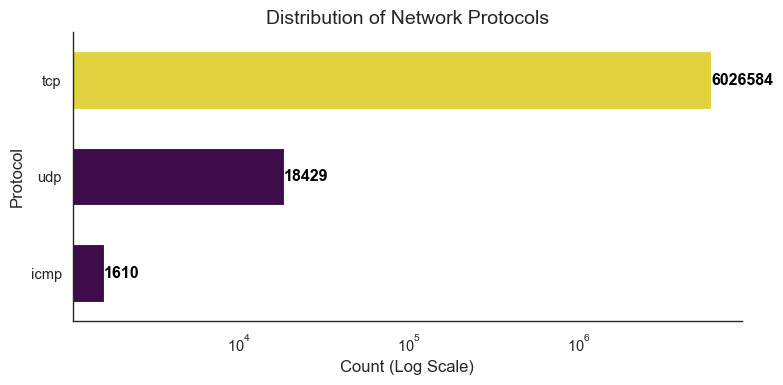

In [9]:
protocol_counts = df['protocol'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=protocol_counts.values, y=protocol_counts.index, width=0.6, hue=protocol_counts.values, palette='viridis', legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Network Protocols', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Protocol', fontsize=12)
plt.xscale('log')

for i, v in enumerate(protocol_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/protocol_bar_chart.pdf', dpi=300, bbox_inches='tight')

Plot label frequencies

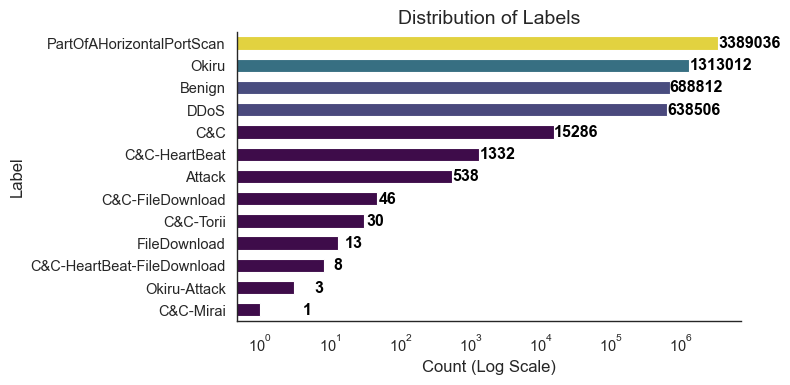

In [10]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=label_counts.values, y=label_counts.index, width=0.6, hue=label_counts.values, palette='viridis', legend=False)
sns.despine(top=True, right=True)
plt.title('Distribution of Labels', fontsize=14)
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Label', fontsize=12)
plt.xscale('log')

for i, v in enumerate(label_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/label_bar_chart.pdf', dpi=300, bbox_inches='tight')

## 4. Data Preparation

Convert labels into boolean values. True for attack, False for benign.

In [11]:
df['is_attack'] = np.where(df['label'] == 'Benign', 0, 1).astype(bool)
df = df.drop(columns=['label'])
df['is_attack'].value_counts()

is_attack
True     5357811
False     688812
Name: count, dtype: int64

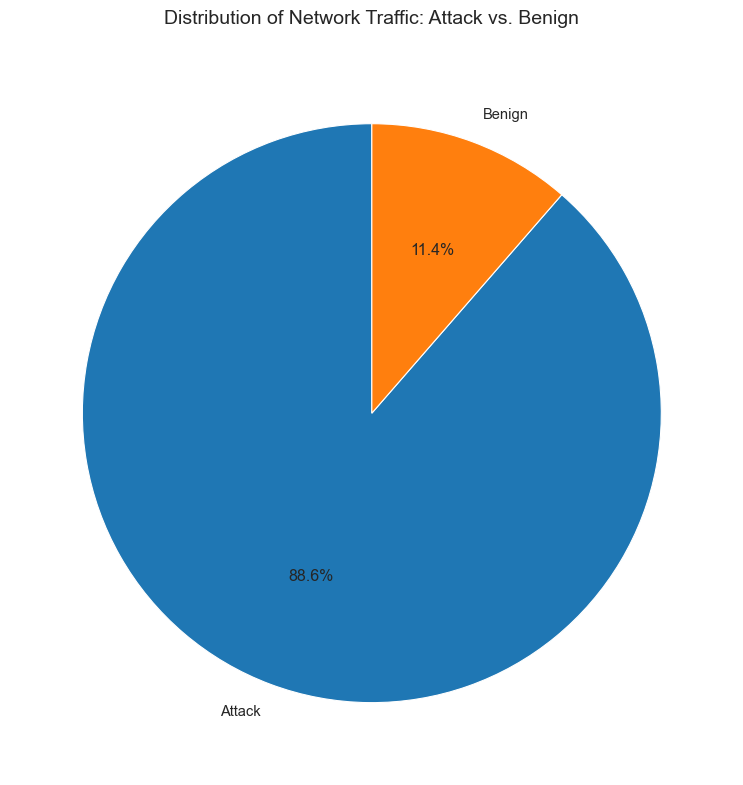

In [12]:
plt.figure(figsize=(8, 8))
plt.pie(
    df['is_attack'].value_counts(),
    labels=['Attack', 'Benign'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Network Traffic: Attack vs. Benign', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('graphs/attack_benign_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print(df.dtypes)

timestamp                         float64
source_port                       float64
dest_port                         float64
protocol                              str
service                               str
duration                              str
payload_bytes_sent_from_source        str
payload_bytes_sent_from_dest          str
connection_state                      str
missed_bytes                      float64
packets_sent_from_source          float64
ip_bytes_sent_from_source         float64
packets_sent_from_dest            float64
ip_bytes_sent_from_dest           float64
is_attack                            bool
dtype: object


Change data types of features

In [14]:
# List the columns that should be numbers but are currently 'str'
numeric_cols = [
    'duration',
    'payload_bytes_sent_from_source',
    'payload_bytes_sent_from_dest'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill the new NaNs with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

In [15]:
# List of columns that should be whole numbers
int_cols = [
    'source_port', 'dest_port', 'missed_bytes',
    'packets_sent_from_source', 'packets_sent_from_dest',
    'payload_bytes_sent_from_source', 'payload_bytes_sent_from_dest',
    'ip_bytes_sent_from_source', 'ip_bytes_sent_from_dest'
]

df[int_cols] = df[int_cols].astype('Int64')

In [16]:
# List of columns that should be categorical
cat_cols = ['protocol', 'service', 'connection_state']

for col in cat_cols:
    df[col] = df[col].astype('category')

One-hot encode catagorical features

In [17]:
# Select the categorical columns
categorical_cols = ['protocol', 'service', 'connection_state']

# This will transform them into multiple 0/1 columns
df = pd.get_dummies(df, columns=categorical_cols)

In [18]:
# Replace any remaining hidden inf values with 0
df = df.replace([np.inf, -np.inf], 0)

# Fill any remaining NaNs with 0
df = df.fillna(0)

## 4. Feature Engineering

Create Inter-Arrival-Time (IAT) feature

In [19]:
df["inter_arrival_time"] = df["timestamp"].diff().fillna(0)
df.drop(columns=["timestamp"], inplace=True)
df.head()

,source_port,dest_port,duration,payload_bytes_sent_from_source,payload_bytes_sent_from_dest,missed_bytes,packets_sent_from_source,ip_bytes_sent_from_source,packets_sent_from_dest,ip_bytes_sent_from_dest,...,connection_state_RSTR,connection_state_RSTRH,connection_state_S0,connection_state_S1,connection_state_S2,connection_state_S3,connection_state_SF,connection_state_SH,connection_state_SHR,inter_arrival_time
0,17576,8081,0.000003,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000000
1,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000005
2,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000004
3,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000012
4,17576,8081,0.000002,0,0,0,2,80,0,0,...,False,False,True,False,False,False,False,False,False,0.000004


Create avg packet size features

In [20]:
df['avg_packet_size_source'] = (df['ip_bytes_sent_from_source'] / df['packets_sent_from_source']).replace([np.inf, -np.inf], 0).fillna(0)
df['avg_packet_size_dest'] = (df['ip_bytes_sent_from_dest'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create throughput feature

In [21]:
df['throughput'] = (df['ip_bytes_sent_from_source'] / df['duration']).replace([np.inf, -np.inf], 0).fillna(0)

Create packet ratio feature

In [22]:
df['packet_ratio'] = (df['packets_sent_from_source'] / df['packets_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

Create byte ratio feature

In [23]:
df['byte_ratio'] = (df['payload_bytes_sent_from_source'] / df['payload_bytes_sent_from_dest']).replace([np.inf, -np.inf], 0).fillna(0)

## 5. Split Data

Split the data into training and test tests

In [24]:
X = df.drop(columns=['is_attack'])
y = df['is_attack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Scaling

Scale values

In [25]:
# Scale, fit on training data only
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

## 6. Balancing

Downsample the training dataset to 100,000 samples.

In [26]:
# Create train_df using the already-scaled DataFrame
train_df = X_train_scaled.copy()
train_df['is_attack'] = y_train.values

df_attack = train_df[train_df['is_attack'] == 1].sample(n=50000, replace=True, random_state=42)
df_normal = train_df[train_df['is_attack'] == 0].sample(n=50000, replace=True, random_state=42)
df_scaled_balanced = pd.concat([df_attack, df_normal]).sample(frac=1, random_state=42)

X_train_final = df_scaled_balanced.drop(columns=['is_attack'])
y_train_final = df_scaled_balanced['is_attack']

## 7. Training

Train base model

In [27]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 8. Evaluation

In [28]:
print(f"Number of features: {len(X.columns)}")

Number of features: 39


Evaluate the base model

In [29]:
y_pred = rf_base.predict(X_test_scaled)
print("--- Base RF Model Classification Report ---")
print(classification_report(y_test, y_pred))

--- Base RF Model Classification Report ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    137762
        True       1.00      1.00      1.00   1071563

    accuracy                           1.00   1209325
   macro avg       1.00      1.00      1.00   1209325
weighted avg       1.00      1.00      1.00   1209325



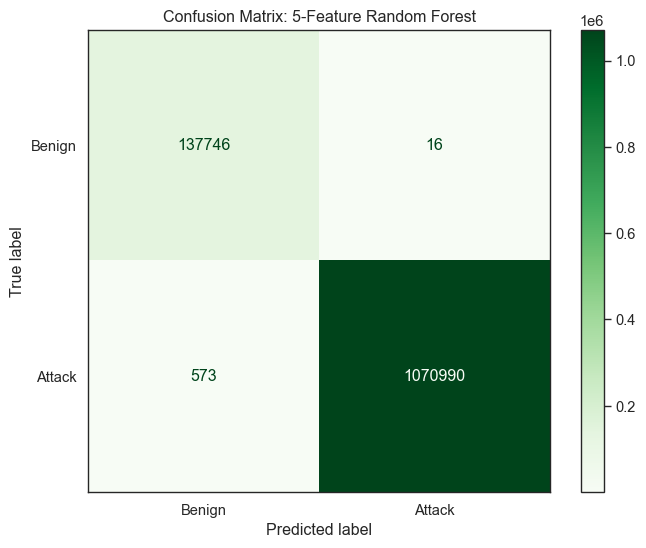

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    values_format='d',
    ax=ax
)
plt.title("Confusion Matrix: 5-Feature Random Forest")
plt.show()

Feature Importance

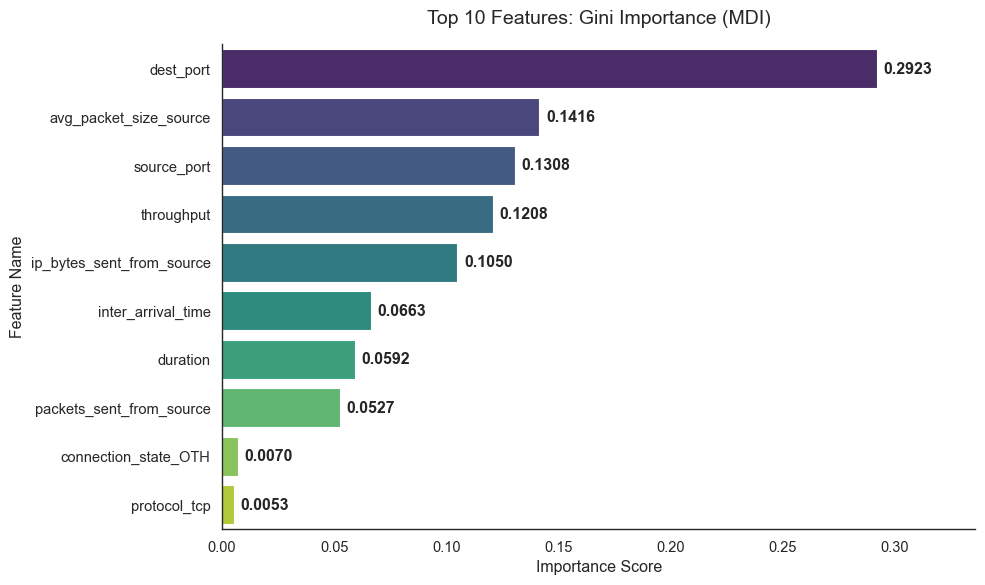

In [31]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_base.feature_importances_
})

# MDI importance plot
top_10_mdi = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True).head(10)

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(
    data=top_10_mdi,
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_mdi['importance']):
    ax1.text(v + (top_10_mdi['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

plt.title("Top 10 Features: Gini Importance (MDI)", fontsize=14, pad=15)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_mdi['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_mdi.pdf', bbox_inches='tight')
plt.show()

Calculating Permutation Importance


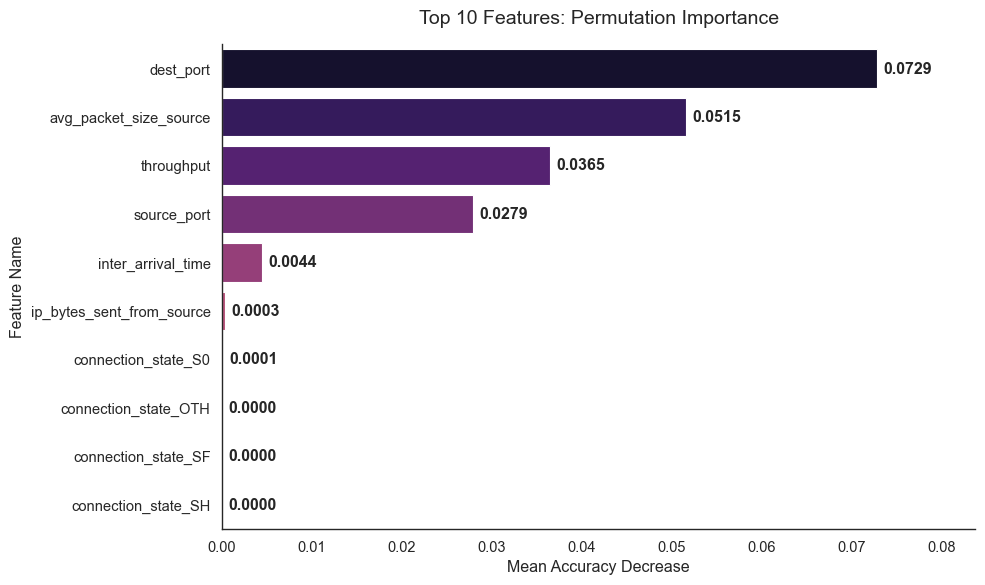


Meaningful Features (Permutation > 0.001):
['dest_port', 'avg_packet_size_source', 'throughput', 'source_port', 'inter_arrival_time']


In [32]:
# Permutation Importance Plot (More Reliable)
print("Calculating Permutation Importance")

# Sample 50k rows from the test set for speed
X_test_sample = X_test_scaled.sample(n=50000, random_state=42)
y_test_sample = y_test.iloc[X_test_sample.index]

perm = permutation_importance(
    rf_base, X_test_sample, y_test_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

top_10_perm = perm_importance.head(10)

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(
    data=top_10_perm,
    x='importance',
    y='feature',
    hue='feature',
    palette='magma',
    legend=False
)
sns.despine()

for i, v in enumerate(top_10_perm['importance']):
    ax2.text(v + (top_10_perm['importance'].max() * 0.01), i, f'{v:.4f}',
             va='center', fontweight='semibold')

plt.title("Top 10 Features: Permutation Importance", fontsize=14, pad=15)
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature Name")
plt.xlim(0, top_10_perm['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('graphs/feature_importance_permutation.pdf', bbox_inches='tight')
plt.show()

print("\nMeaningful Features (Permutation > 0.001):")
meaningful_features = perm_importance[perm_importance['importance'] > 0.001]
print(meaningful_features['feature'].tolist())

Select the top features

In [33]:
# Create dataframe containing only meaningful features
X_meaningful = X[meaningful_features['feature'].tolist()]

X_meaningful.head()

,dest_port,avg_packet_size_source,throughput,source_port,inter_arrival_time
0,8081,40.0,26666666.666667,17576,0.000000
1,8081,40.0,40000000.0,17576,0.000005
2,8081,40.0,40000000.0,17576,0.000004
3,8081,40.0,40000000.0,17576,0.000012
4,8081,40.0,40000000.0,17576,0.000004


In [34]:
# Split the raw meaningful features
X_train_meaningful, X_test_meaningful, y_train_meaningful, y_test_meaningful = train_test_split(
    X_meaningful, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler_meaningful = RobustScaler()

X_train_m_scaled_df = pd.DataFrame(
    scaler_meaningful.fit_transform(X_train_meaningful),
    columns=X_train_meaningful.columns
)

X_test_m_scaled_df = pd.DataFrame(
    scaler_meaningful.transform(X_test_meaningful),
    columns=X_test_meaningful.columns
)

# Balance
train_m_df = X_train_m_scaled_df.copy()
train_m_df['is_attack'] = y_train_meaningful.values

df_m_attack = train_m_df[train_m_df['is_attack'] == 1].sample(n=50000, replace=True, random_state=42)
df_m_normal = train_m_df[train_m_df['is_attack'] == 0].sample(n=50000, replace=True, random_state=42)
df_m_balanced = pd.concat([df_m_attack, df_m_normal]).sample(frac=1, random_state=42)

# Final Training Features and Labels
X_train_meaningful_final = df_m_balanced.drop(columns=['is_attack'])
y_train_meaningful_final = df_m_balanced['is_attack']

# Train the 5-Feature Model
rf_meaningful = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_meaningful.fit(X_train_meaningful_final, y_train_meaningful_final)

# Evaluate on the original (imbalanced) scaled test set
y_pred_meaningful = rf_meaningful.predict(X_test_m_scaled_df)

print("--- 5-Feature Performance (Optimized Model) ---")
print(classification_report(y_test_meaningful.values, y_pred_meaningful))

--- 5-Feature Performance (Optimized Model) ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    137762
        True       1.00      1.00      1.00   1071563

    accuracy                           1.00   1209325
   macro avg       1.00      1.00      1.00   1209325
weighted avg       1.00      1.00      1.00   1209325



Even with only five features, reduced down from thirty-nine. The model still performs well with perfect scores.

Plot confusion matrix for the RF model using only the five most important features

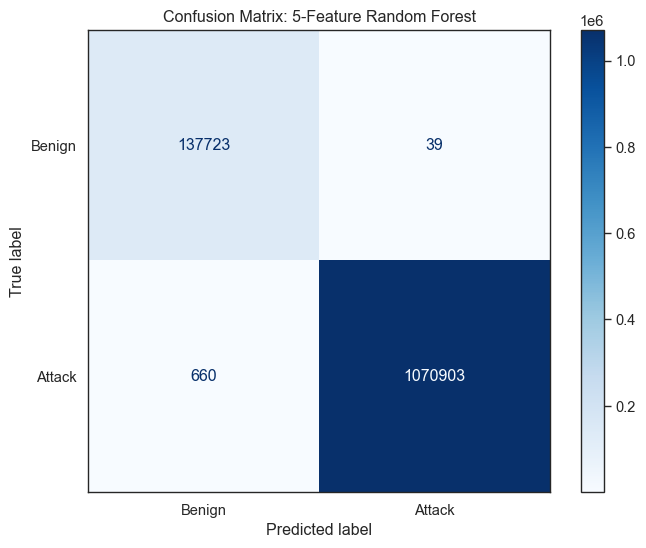

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful,
    y_pred_meaningful,
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    values_format='d',
    ax=ax
)
plt.title("Confusion Matrix: 5-Feature Random Forest")
plt.show()

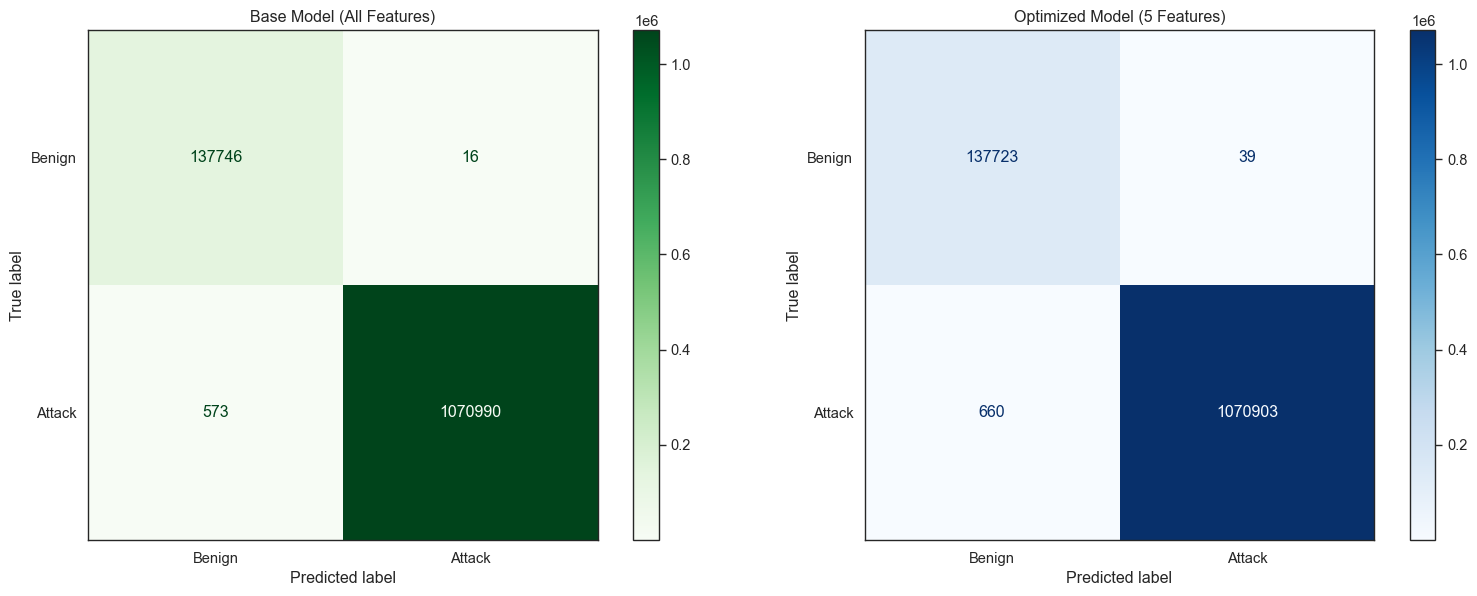

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Base Model Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test.values,
    y_pred, # This is from your rf_base
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    ax=ax1,
    values_format='d'
)
ax1.set_title("Base Model (All Features)")

# 2. 5-Feature Model Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_meaningful, # This is from your rf_meaningful
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    ax=ax2,
    values_format='d'
)
ax2.set_title("5-Feature Model")

plt.tight_layout()
plt.savefig('graphs/model_comparison_matrices.pdf')
plt.show()

Save the model

In [37]:
# Save the model and scaler
joblib.dump(rf_meaningful, 'models/random_forest_iot23.joblib')
joblib.dump(scaler_meaningful, 'models/scaler_iot23.joblib')

# Check file size in KB
size_kb = os.path.getsize('models/random_forest_iot23.joblib') / 1024
print(f"Random Forest Model Size: {size_kb:.2f} KB")

Random Forest Model Size: 2809.29 KB


## 9. Optimisation

Currently, the model size is ~2800KB. This is too large for the ESP32 512KB RAM.

In [38]:
print(f"{'Trees':<6} | {'Depth':<6} | {'Accuracy':<10} | {'F1-Score':<10} | {'C++ Lines':<10}")
print("-" * 55)

for trees in [5, 10]:
    for depth in [3, 5, 7, 10, 12, 15, 20]:
        test_rf = RandomForestClassifier(n_estimators=trees, max_depth=depth, random_state=42, n_jobs=-1)
        test_rf.fit(X_train_meaningful_final, y_train_meaningful_final)

        preds = test_rf.predict(X_test_m_scaled_df)
        acc = test_rf.score(X_test_m_scaled_df, y_test_meaningful)
        f1 = f1_score(y_test_meaningful, preds)

        # Export to C code
        temp_code = m2c.export_to_c(test_rf)
        lines = len(temp_code.split('\n'))

        print(f"{trees:<6} | {depth:<6} | {acc:<10.4f} | {f1:<10.4f} | {lines:<10}")

Trees  | Depth  | Accuracy   | F1-Score   | C++ Lines 
-------------------------------------------------------
5      | 3      | 0.8751     | 0.9244     | 169       
5      | 5      | 0.9710     | 0.9834     | 513       
5      | 7      | 0.9770     | 0.9869     | 1021      
5      | 10     | 0.9934     | 0.9963     | 1833      
5      | 12     | 0.9984     | 0.9991     | 2305      
5      | 15     | 0.9995     | 0.9997     | 2833      
5      | 20     | 0.9994     | 0.9997     | 2957      
10     | 3      | 0.9503     | 0.9712     | 329       
10     | 5      | 0.9708     | 0.9833     | 1017      
10     | 7      | 0.9802     | 0.9887     | 2137      
10     | 10     | 0.9887     | 0.9936     | 3921      
10     | 12     | 0.9937     | 0.9964     | 4681      
10     | 15     | 0.9992     | 0.9995     | 5869      
10     | 20     | 0.9993     | 0.9996     | 6493      


Using five trees actually produces better accuracy and F1-scores compared to ten trees, while also remaining smaller in memory (C++ Lines).
The combination of five trees and a depth of 15 appears best. It provides the highest accuracy and joint-highest f1 across the board.

In [39]:
# Create the model with the optimised parameters (5 trees, 15 depth)
rf_optimised = RandomForestClassifier(n_estimators=5, max_depth=15, random_state=42)

# Create the pipeline for Cross-Validation
cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('rf', RandomForestClassifier(n_estimators=5, max_depth=15, random_state=42))
])

# Perform Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train_meaningful, y_train_meaningful, cv=kf)

print("--- Cross-Validation Results ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Stability (Std Dev): {cv_scores.std():.4f}")

# Overfitting Check (Train vs Test)
rf_optimised.fit(X_train_meaningful_final, y_train_meaningful_final)

train_acc = rf_optimised.score(X_train_meaningful_final, y_train_meaningful_final)
test_acc = rf_optimised.score(X_test_m_scaled_df, y_test_meaningful)

print("\n--- Generalization Check ---")
print(f"Training Accuracy (Balanced): {train_acc*100:.2f}%")
print(f"Testing Accuracy (Imbalanced): {test_acc*100:.2f}%")
print(f"The 'Gap': {(train_acc - test_acc)*100:.4f}%")

if (train_acc - test_acc) > 0.05:
    print("WARNING: Model may be overfitting (Gap > 5%)")
else:
    print("SUCCESS: Model generalizes well to unseen data.")

# Check Size
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(rf_optimised, 'models/rf_optimised.joblib')
optimised_size_kb = os.path.getsize('models/rf_optimised.joblib') / 1024
print(f"\nPC Model Size (Joblib): {optimised_size_kb:.2f} KB")

--- Cross-Validation Results ---
Individual Fold Scores: [0.99995039 0.99993695 0.99993798 0.99994108 0.99994212]
Mean Accuracy: 99.99%
Stability (Std Dev): 0.0000

--- Generalization Check ---
Training Accuracy (Balanced): 99.99%
Testing Accuracy (Imbalanced): 99.95%
The 'Gap': 0.0442%
SUCCESS: Model generalizes well to unseen data.

PC Model Size (Joblib): 113.49 KB


--- Optimised RF (5 Trees, Depth 15) Performance ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    137762
        True       1.00      1.00      1.00   1071563

    accuracy                           1.00   1209325
   macro avg       1.00      1.00      1.00   1209325
weighted avg       1.00      1.00      1.00   1209325



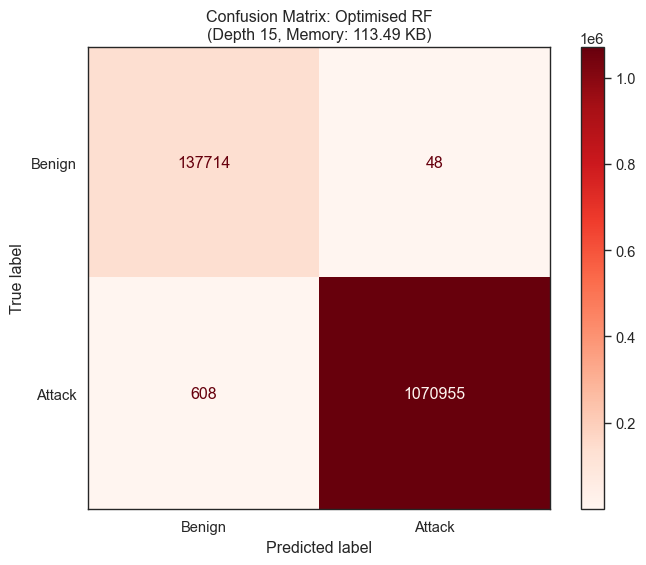

In [40]:
y_pred_optimised = rf_optimised.predict(X_test_m_scaled_df)

print("--- Optimised RF (5 Trees, Depth 15) Performance ---")
print(classification_report(y_test_meaningful.values, y_pred_optimised))

# Plot the final confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_optimised,
    display_labels=['Benign', 'Attack'],
    cmap='Reds',
    values_format='d',
    ax=ax
)

plt.title(f"Confusion Matrix: Optimised RF\n(Depth 15, Memory: {optimised_size_kb:.2f} KB)")
plt.show()

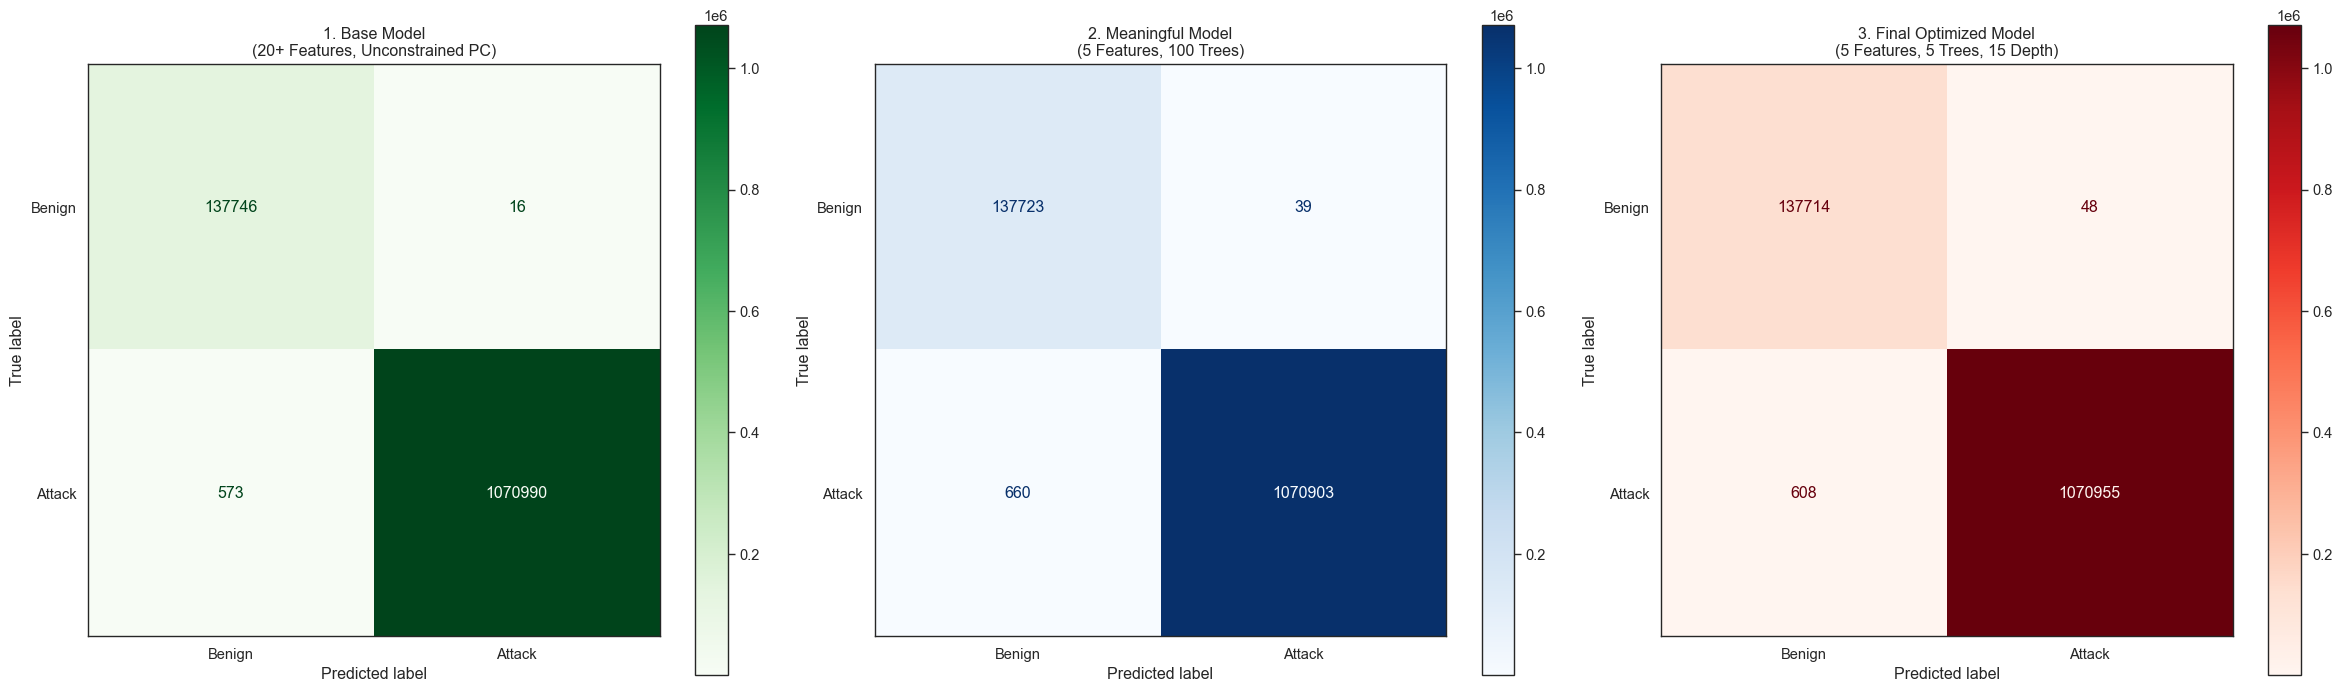

Figure saved as: graphs/complete_model_comparison_matrices.pdf


In [46]:
# Create a 3-column grid for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Base Model (Full 39 Features)
y_pred_base = rf_base.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(
    y_test.values,
    y_pred_base,
    display_labels=['Benign', 'Attack'],
    cmap='Greens',
    values_format='d',
    ax=axes[0]
)
axes[0].set_title("1. Base Model\n(20+ Features, Unconstrained PC)")

# Meaningful Model (5 Features, Unoptimised)
y_pred_m = rf_meaningful.predict(X_test_m_scaled_df)
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_m,
    display_labels=['Benign', 'Attack'],
    cmap='Blues',
    values_format='d',
    ax=axes[1]
)
axes[1].set_title("2. Meaningful Model\n(5 Features, 100 Trees)")

# Final Optimised Model (5 Features, 5 Trees, 15 Depth)
y_pred_opt = rf_optimised.predict(X_test_m_scaled_df)
ConfusionMatrixDisplay.from_predictions(
    y_test_meaningful.values,
    y_pred_opt,
    display_labels=['Benign', 'Attack'],
    cmap='Reds',
    values_format='d',
    ax=axes[2]
)
axes[2].set_title(f"3. Final Optimized Model\n(5 Features, 5 Trees, 15 Depth)")

plt.tight_layout()
plt.savefig('graphs/complete_model_comparison_matrices.pdf', bbox_inches='tight')
plt.show()

print("Figure saved as: graphs/complete_model_comparison_matrices.pdf")

## 10. Exportation

In [41]:
# Capture Scaler Parameters used for C++ implementation
print("--- SCALER PARAMETERS for ESP32 ---")
feature_list = X_train_meaningful.columns.tolist()

for i, feature in enumerate(feature_list):
    print(f"Feature: {feature}")
    print(f"  Median (Center): {scaler_meaningful.center_[i]:.8f}")
    print(f"  IQR (Scale):     {scaler_meaningful.scale_[i]:.8f}")
    print("-" * 30)

--- SCALER PARAMETERS for ESP32 ---
Feature: dest_port
  Median (Center): 8081.00000000
  IQR (Scale):     37192.00000000
------------------------------
Feature: avg_packet_size_source
  Median (Center): 40.00000000
  IQR (Scale):     1.00000000
------------------------------
Feature: throughput
  Median (Center): 0.00000000
  IQR (Scale):     13333333.33333333
------------------------------
Feature: source_port
  Median (Center): 36182.00000000
  IQR (Scale):     28282.00000000
------------------------------
Feature: inter_arrival_time
  Median (Center): 0.00000596
  IQR (Scale):     0.00024295
------------------------------


Convert to c++

In [42]:
# Export Model to C++
code = m2c.export_to_c(rf_optimised)
if not os.path.exists('models'): os.makedirs('models')
with open("models/optimised_rf_model.h", "w") as f:
    f.write(code)
print("C++ Header File Generated: models/optimised_rf_model.h\n")

C++ Header File Generated: models/optimised_rf_model.h



Convert unscaled test samples to C++ so scaling + inference can be tested

In [43]:
# Grab Raw Unscaled Samples
raw_attacks = X_test_meaningful[y_test_meaningful == 1].head(5).values
raw_benign = X_test_meaningful[y_test_meaningful == 0].head(5).values

print("double raw_samples[10][5] = {")
for row in list(raw_attacks) + list(raw_benign):
    print("  {" + ", ".join(map(str, row)) + "},")
print("};\n")

double raw_samples[10][5] = {
  {37215, 40.0, 0.0, 36097, 0.00024318695068359375},
  {62336, 0.0, 0.0, 33706, 0.4682581424713135},
  {37215, 40.0, 0.0, 36097, 0.0002410411834716797},
  {62336, 0.0, 0.0, 58591, 2.1457672119140625e-06},
  {23, 40.0, 40000000.0, 63420, 3.0994415283203125e-06},
  {23, 60.0, 57.08917519462651, 58610, 6.9141387939453125e-06},
  {23, 60.0, 0.0, 50306, 3.0994415283203125e-06},
  {23, 60.0, 56.989077093557064, 52444, 0.00022983551025390625},
  {23, 60.0, 57.46746623068015, 56042, 0.010236978530883789},
  {23, 60.0, 0.0, 58104, 7.152557373046875e-06},
};



Convert scaled test samples to C++ so a larger sample set can be used for inference testing

In [47]:
# Grab 500 Scaled Samples for "Model Only" Testing
test_samples = X_test_m_scaled_df.iloc[:500].values
test_labels = y_test_meaningful.iloc[:500].values

print(f"double large_test_set[500][5] = {{")
for row in test_samples:
    print("  {" + ", ".join(map(str, row)) + "},")
print("};\n")

double large_test_set[500][5] = {
  {0.7833405033340504, 0.0, 0.0, -0.0030054451594653843, 0.9764474975466143},
  {1.4587814583781458, -40.0, 0.0, -0.08754684958630932, 1927.3719332679098},
  {0.7833405033340504, 0.0, 0.0, -0.0030054451594653843, 0.9676153091265947},
  {1.4587814583781458, -40.0, 0.0, 0.7923414185701153, -0.015701668302257114},
  {-0.21665949666594966, 0.0, 3.0000000000000004, 0.9630860618060958, -0.011776251226692836},
  {0.0, 0.0, 1.2, -0.42511137826179196, 1.0},
  {-0.21665949666594966, 20.0, 4.281688139596989e-06, 0.7930132239587017, 0.003925417075564278},
  {-0.21665949666594966, 20.0, 4.5, 0.8331801145604979, -0.011776251226692836},
  {-0.21665949666594966, 20.0, 4.5, 0.6969096952125027, -0.012757605495583905},
  {-0.21665949666594966, 20.0, 8.688690028730602e-06, 0.5824906300827382, -0.011776251226692836},
  {0.7833405033340504, 0.0, 0.0, -1.083940315394951, 0.9990186457311089},
  {1.4587814583781458, -40.0, 0.0, -0.48150767272470124, -0.012757605495583905},
  {

In [48]:
print("int true_labels[500] = {")
print("  " + ", ".join(map(str, [int(x) for x in test_labels])))
print("};\n")

int true_labels[500] = {
  1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

## 11. Visualisation

Plot one of the trees

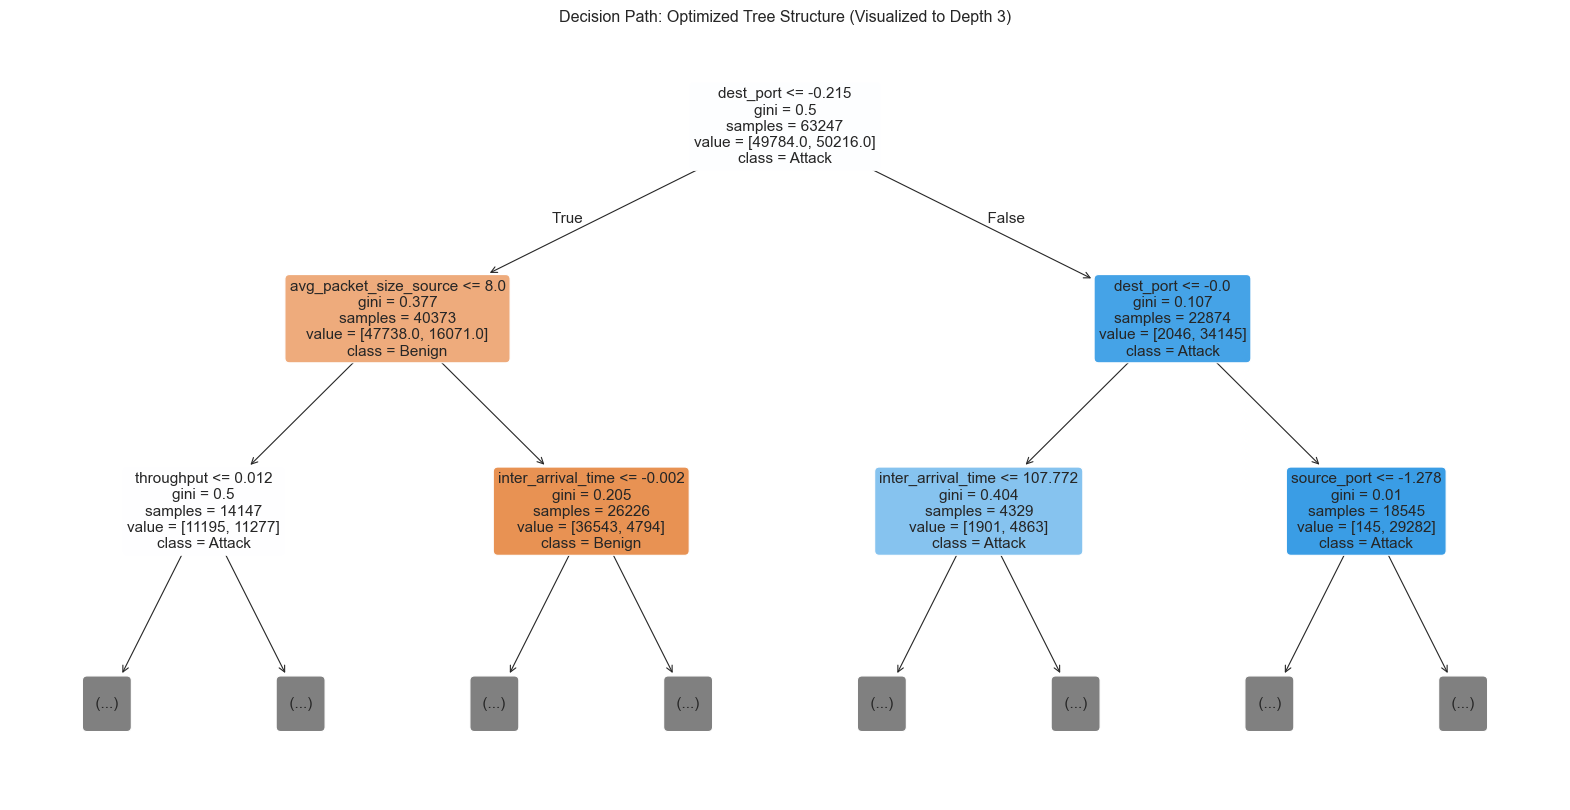

In [49]:
# Visualise the Decision Tree Logic
plt.figure(figsize=(20, 10))
plot_tree(rf_optimised.estimators_[0],
          feature_names=feature_list,
          class_names=['Benign', 'Attack'],
          filled=True,
          rounded=True,
          fontsize=11,
          max_depth=2)
plt.title("Decision Path: Optimized Tree Structure (Visualized to Depth 3)")
plt.savefig("graphs/decision_tree_logic.pdf", bbox_inches='tight')
plt.show()